In [41]:
# ==========================================
# BLOCK 1: INSTALLATIONS & IMPORTS
# ==========================================
!pip install pm4py

import pandas as pd
from collections import Counter, defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import pm4py

print("Environment setup complete.")

Environment setup complete.


In [42]:
# ==========================================
# LOAD XES FILE FROM COLAB FILES
# ==========================================
import pm4py

file_name = "/content/hospital_sepsis_event_log.xes"   # change this


print("Loading XES file...")
log = pm4py.read_xes(file_name)

# Stats
df_stats = pm4py.convert_to_dataframe(log)
print(f"Total Cases: {df_stats['case:concept:name'].nunique()}")
print(f"Total Events: {len(df_stats)}")

Loading XES file...


parsing log, completed traces ::   0%|          | 0/980 [00:00<?, ?it/s]

Total Cases: 980
Total Events: 5590


--- Generating Raw Spaghetti Graph (100% Data) ---
This represents the unreadable visual complexity of the raw event log.


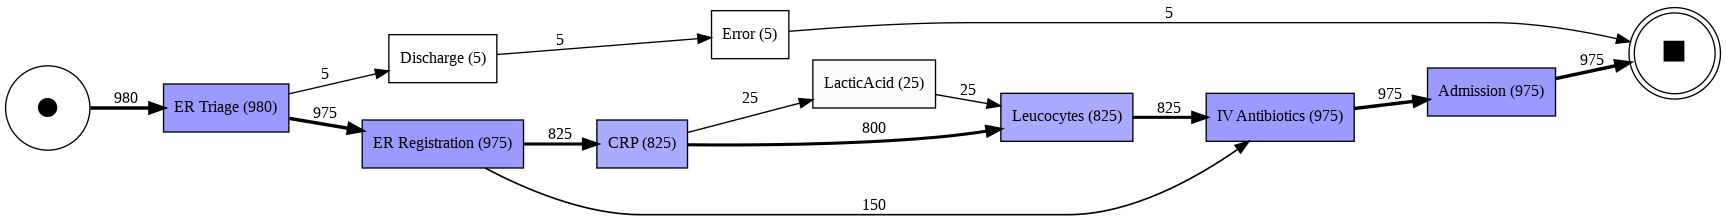

In [43]:
# ==========================================
# BLOCK 4: RAW SPAGHETTI GRAPH (GROUND TRUTH 1)
# ==========================================
print("--- Generating Raw Spaghetti Graph (100% Data) ---")
print("This represents the unreadable visual complexity of the raw event log.")

# Discover and view the Directly-Follows Graph for all data
raw_dfg, raw_start, raw_end = pm4py.discover_dfg(log)
pm4py.view_dfg(raw_dfg, raw_start, raw_end)

--- Generating Heuristics Miner ---


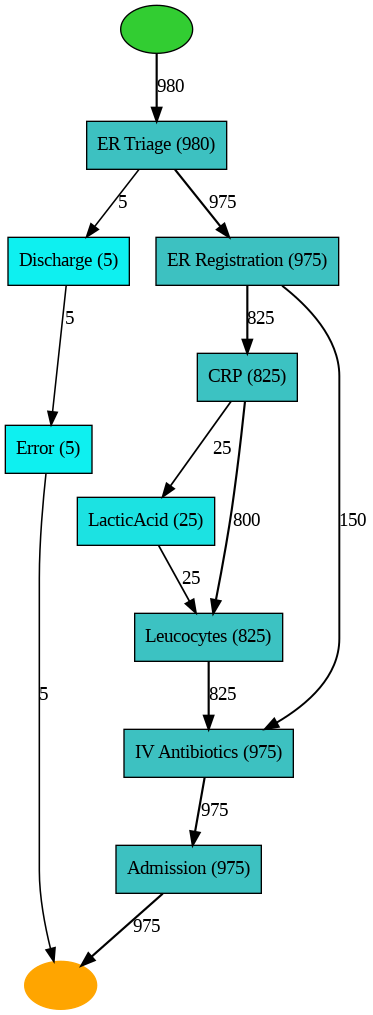

--- Generating Alpha Miner ---


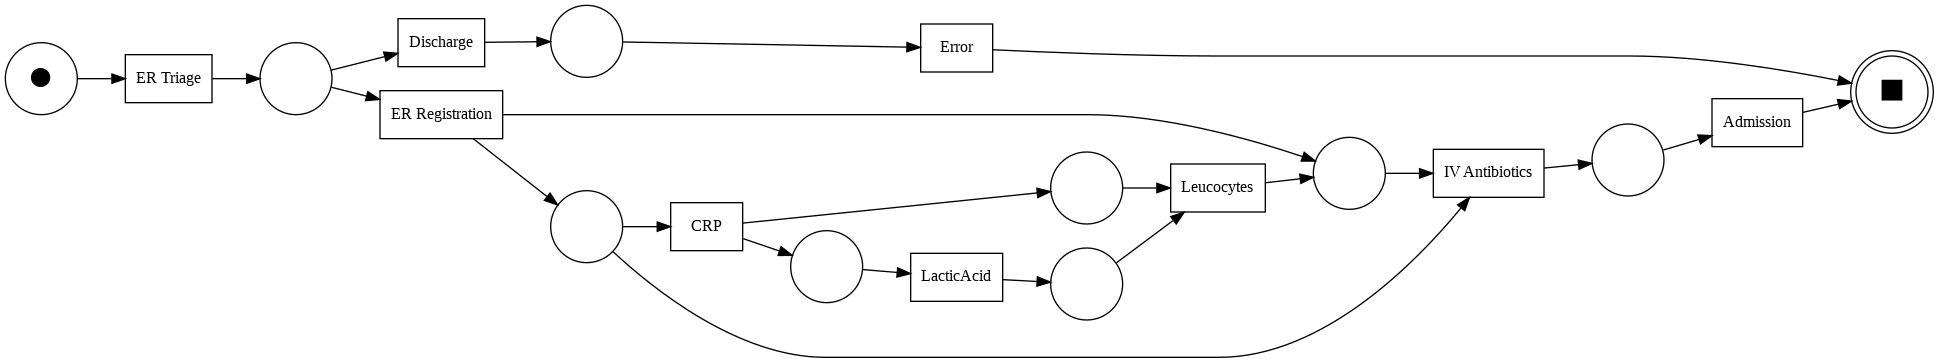

In [44]:
# ==========================================
# BLOCK 5: ALPHA & HEURISTICS MINERS (GROUND TRUTH 2)
# ==========================================
print("--- Generating Heuristics Miner ---")
# Heuristics miner handles some noise but usually remains complex without clustering
heu_net = pm4py.discover_heuristics_net(log)
pm4py.view_heuristics_net(heu_net)

print("--- Generating Alpha Miner ---")
# Alpha miner struggles heavily with real-world noisy logs
net, initial_marking, final_marking = pm4py.discover_petri_net_alpha(log)
pm4py.view_petri_net(net, initial_marking, final_marking)

--- Simulating Celonis Case Coverage Filtering ---
Celonis Logic: Keeping top variants until 80% of total case volume is reached.

Total Cases BEFORE Celonis Filter: 980
Total Cases AFTER Celonis Filter:  950
Data Lost: 30 cases were deleted to make the graph clean.



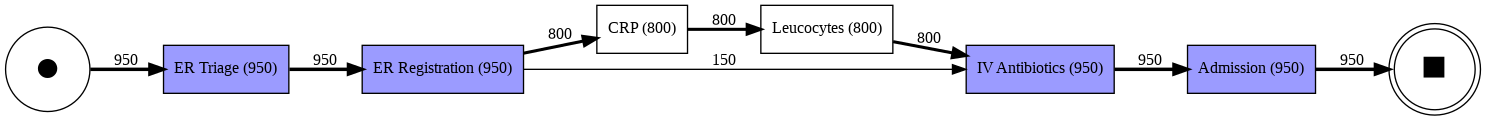

In [45]:
# ==========================================
# BLOCK 6: CELONIS SIMULATION (80% COVERAGE BASELINE)
# ==========================================
print("--- Simulating Celonis Case Coverage Filtering ---")
print("Celonis Logic: Keeping top variants until 80% of total case volume is reached.\n")

# Apply the Celonis 80% Coverage Filter (New pm4py API)
celonis_filtered_log = pm4py.filter_variants_by_coverage_percentage(log, 0.10)

# Check how much data was thrown in the trash
filtered_df = pm4py.convert_to_dataframe(celonis_filtered_log)
retained_cases = filtered_df['case:concept:name'].nunique()
total_raw_cases = df_stats['case:concept:name'].nunique()

print(f"Total Cases BEFORE Celonis Filter: {total_raw_cases}")
print(f"Total Cases AFTER Celonis Filter:  {retained_cases}")
print(f"Data Lost: {total_raw_cases - retained_cases} cases were deleted to make the graph clean.\n")

# Generate the filtered Celonis graph
celonis_dfg, celonis_start, celonis_end = pm4py.discover_dfg(celonis_filtered_log)
pm4py.view_dfg(celonis_dfg, celonis_start, celonis_end)

In [46]:
# ==========================================
# BLOCK 7: PROPOSED MODEL ENGINE (GED & CLUSTERING)
# ==========================================

def calculate_ged(seq1, seq2):
    """Calculates Graph Edit Distance (Levenshtein) between two traces."""
    m, n = len(seq1), len(seq2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if seq1[i-1] == seq2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return dp[m][n]

def explainable_variant_reduction(event_log_df, K=5, max_ged=3, noise_floor=2, intra_threshold_pct=0.02, promotion_vol=50):
    """Core algorithm for clustering and explainable variant reduction."""

    traces = event_log_df.groupby('Case_ID')['Activity'].apply(tuple).tolist()
    variant_counts = Counter(traces)
    total_cases = sum(variant_counts.values())

    # Pre-filter absolute noise
    clean_variants = {v: f for v, f in variant_counts.items() if f > noise_floor}
    noise_removed = len(variant_counts) - len(clean_variants)
    sorted_variants = sorted(clean_variants.items(), key=lambda x: x[1], reverse=True)

    # Initialize Main Clusters
    actual_K = min(K, len(sorted_variants))
    main_clusters = {v[0]: {'base_freq': v[1], 'clustered_traces': [], 'total_freq': v[1]} for v in sorted_variants[:actual_K]}
    rare_variants = sorted_variants[actual_K:]

    explanation_log = []
    exception_log = []

    # Clustering via GED
    for rare_var, freq in rare_variants:
        best_main = None
        min_ged = float('inf')
        for main_var in main_clusters.keys():
            if abs(len(rare_var) - len(main_var)) > max_ged:
                continue
            dist = calculate_ged(rare_var, main_var)
            if dist < min_ged:
                min_ged = dist
                best_main = main_var

        if min_ged <= max_ged:
            main_clusters[best_main]['clustered_traces'].append((rare_var, freq, min_ged))
            main_clusters[best_main]['total_freq'] += freq
            explanation_log.append(f"CLUSTERED: {rare_var} → {best_main} (GED={min_ged}, Vol={freq})")
        else:
            if freq >= promotion_vol:
                main_clusters[rare_var] = {'base_freq': freq, 'clustered_traces': [], 'total_freq': freq}
                explanation_log.append(f"PROMOTED: {rare_var} (Vol={freq})")
            else:
                exception_log.append((rare_var, freq))
                explanation_log.append(f"EXCEPTION: {rare_var} (Vol={freq}, ignored for visual clarity)")

    # Intra-Cluster Edge Filtering
    final_edges = defaultdict(int)
    for main_var, data in main_clusters.items():
        cluster_total = data['total_freq']
        local_edges = defaultdict(int)

        for i in range(len(main_var) - 1):
            local_edges[(main_var[i], main_var[i+1])] += data['base_freq']
        for trace, freq, _ in data['clustered_traces']:
            for i in range(len(trace) - 1):
                local_edges[(trace[i], trace[i+1])] += freq

        for edge, freq in local_edges.items():
            if (freq / cluster_total) >= intra_threshold_pct:
                final_edges[edge] += freq

    return {
        'total_cases': total_cases,
        'noise_removed': noise_removed,
        'edges': dict(final_edges),
        'logs': explanation_log,
        'exceptions': exception_log
    }

In [47]:
# ==========================================
# BLOCK 8: RUNNING THE PROPOSED MODEL
# ==========================================

# Format DataFrame for custom algorithm
df_model = pm4py.convert_to_dataframe(log)
df_model = df_model.rename(columns={'case:concept:name': 'Case_ID', 'concept:name': 'Activity'})
df_model = df_model[['Case_ID', 'Activity']].dropna()

print("--- Running Proposed Explainable Variant Reduction ---")
results = explainable_variant_reduction(
    event_log_df=df_model,
    K=5,                       # Adjust top K paths
    max_ged=3,                 # Max distance to cluster
    noise_floor=2,             # Drop 1-off system glitches
    intra_threshold_pct=0.02,  # 2% local threshold to save micro-branches
    promotion_vol=50           # Volume needed to promote an outlier
)

print(f"\nTotal Cases Analyzed: {results['total_cases']}")
print(f"Noise Traces Dropped: {results['noise_removed']}")
print(f"Cases assigned to Exception Log: {len(results['exceptions'])}")

--- Running Proposed Explainable Variant Reduction ---

Total Cases Analyzed: 980
Noise Traces Dropped: 0
Cases assigned to Exception Log: 0


--- Our Approach: Explainable Clustering ---
Notice how this uses the same clean visual layout as Celonis, but retains the critical LacticAcid branch!


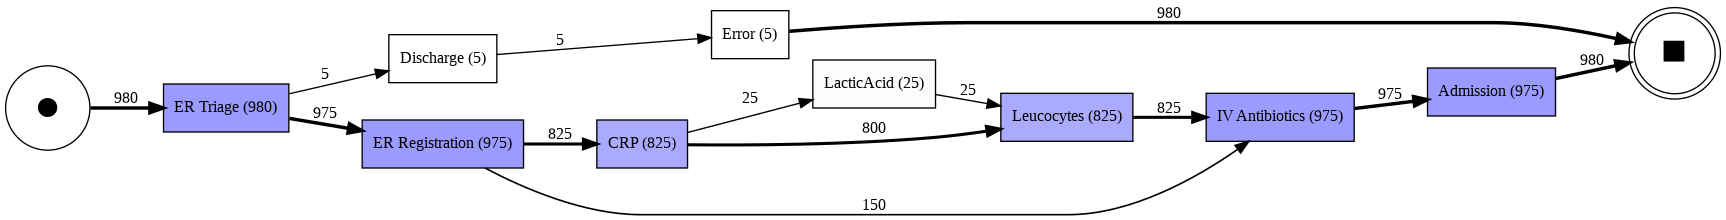

In [48]:
# ==========================================
# BLOCK 9 (UPDATED): VISUALIZE PROPOSED MODEL GRAPH (CELONIS STYLE)
# ==========================================
import pm4py

print("--- Our Approach: Explainable Clustering ---")
print("Notice how this uses the same clean visual layout as Celonis, but retains the critical LacticAcid branch!")

# 1. Get the edges from our proposed algorithm
dfg = results['edges']

# 2. Identify the Start and End activities for the visualizer
sources = set([src for src, dst in dfg.keys()])
targets = set([dst for src, dst in dfg.keys()])

start_nodes = sources - targets
end_nodes = targets - sources

# Give the start/end nodes a default frequency so they render correctly
start_activities = {node: results['total_cases'] for node in start_nodes}
end_activities = {node: results['total_cases'] for node in end_nodes}

# Fallback just in case there are loops hiding the true start/end
if not start_activities:
    start_activities = {"ER Triage": results['total_cases']}
if not end_activities:
    end_activities = {"Admission": results['total_cases'], "Discharge": 5}

# 3. Draw the graph using pm4py's built-in DFG visualizer
# This uses the Graphviz engine (the exact same engine Celonis uses for layout!)
pm4py.view_dfg(dfg, start_activities, end_activities)

In [49]:
# ==========================================
# BLOCK 10: EXPLANATION LOG OUTPUT
# ==========================================
print("--- THE EXPLANATION LOG (Audit Trail) ---\n")

# Print first 25 logs to avoid flooding the screen
for log_entry in results['logs'][:25]:
    print(log_entry)

if len(results['logs']) > 25:
    print(f"... and {len(results['logs']) - 25} more cluster mapping rules generated.")

--- THE EXPLANATION LOG (Audit Trail) ---

